Based on code from https://gymnasium.farama.org/v0.27.1/tutorials/training_agents/reinforce_invpend_gym_v26/

In [40]:
from lerobot.envs.utils import _load_module_from_path, _call_make_env, _normalize_hub_result

# Load your module
module = _load_module_from_path("./inverted_pendulum_env_no_ui.py")

# Test the make_env function
result = _call_make_env(module, n_envs=1, use_async_envs=False)
normalized = _normalize_hub_result(result)

# Verify it works
suite_name = next(iter(normalized))
env = normalized[suite_name][0]
step_log = []

obs, info = env.reset()
reward = 0.0; terminated = False; truncated = False

# mjmodel = env.envs[0].unwrapped.model

# import mujoco as mj
# cart_id = mj.mj_name2id(mjmodel, mj.mjtObj.mjOBJ_BODY, "cart")
# pole_id = mj.mj_name2id(mjmodel, mj.mjtObj.mjOBJ_BODY, "pole")

# m_c = mjmodel.body_mass[cart_id]
# m_p = mjmodel.body_mass[pole_id]
# l = 1
# g = 9.81



In [3]:
from __future__ import annotations

import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.distributions.normal import Normal

import gymnasium as gym


plt.rcParams["figure.figsize"] = (10, 5)

In [ ]:
#@title Policy Network

class Policy_Network(nn.Module):
    """Parametrized Policy Network."""

    def __init__(self, obs_space_dims: int, action_space_dims: int):
        """Initializes a neural network that estimates the mean and standard deviation
         of a normal distribution from which an action is sampled from.

        Args:
            obs_space_dims: Dimension of the observation space
            action_space_dims: Dimension of the action space
        """
        super().__init__()

        hidden_space1 = 16  # Nothing special with 16, feel free to change
        hidden_space2 = 32  # Nothing special with 32, feel free to change

        # Shared Network
        self.shared_net = nn.Sequential(
            nn.Linear(obs_space_dims, hidden_space1),
            nn.Tanh(),
            nn.Linear(hidden_space1, hidden_space2),
            nn.Tanh(),
        )

        # Policy Mean specific Linear Layer
        self.policy_mean_net = nn.Sequential(
            nn.Linear(hidden_space2, action_space_dims)
        )

        # Policy Std Dev specific Linear Layer
        self.policy_stddev_net = nn.Sequential(
            nn.Linear(hidden_space2, action_space_dims)
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Conditioned on the observation, returns the mean and standard deviation
         of a normal distribution from which an action is sampled from.

        Args:
            x: Observation from the environment

        Returns:
            action_means: predicted mean of the normal distribution
            action_stddevs: predicted standard deviation of the normal distribution
        """
        shared_features = self.shared_net(x.float())

        action_means = self.policy_mean_net(shared_features)
        action_stddevs = torch.log(
            1 + torch.exp(self.policy_stddev_net(shared_features))
        )

        return action_means, action_stddevs

In [6]:
#@title REINFORCE Algorithm

class REINFORCE:
    """REINFORCE algorithm."""

    def __init__(self, obs_space_dims: int, action_space_dims: int):
        """Initializes an agent that learns a policy via REINFORCE algorithm [1]
        to solve the task at hand (Inverted Pendulum v4).

        Args:
            obs_space_dims: Dimension of the observation space
            action_space_dims: Dimension of the action space
        """

        # Hyperparameters
        self.learning_rate = 1e-4  # Learning rate for policy optimization
        self.gamma = 0.99  # Discount factor
        self.eps = 1e-6  # small number for mathematical stability

        self.probs = []  # Stores probability values of the sampled action
        self.rewards = []  # Stores the corresponding rewards

        self.net = Policy_Network(obs_space_dims, action_space_dims)
        self.optimizer = torch.optim.AdamW(self.net.parameters(), lr=self.learning_rate)

    def sample_action(self, state: np.ndarray) -> float:
        """Returns and accumulates action, conditioned on the policy and observation.

        The client is expected to add the reward of this action to .rewards.

        Args:
            state: Observation from the environment

        Returns:
            action: Action to be performed
        """
        state = torch.tensor(np.array([state]))
        action_means, action_stddevs = self.net(state)

        # create a normal distribution from the predicted
        #   mean and standard deviation and sample an action
        distrib = Normal(action_means[0] + self.eps, action_stddevs[0] + self.eps)
        action = distrib.sample()
        prob = distrib.log_prob(action)

        action = action.numpy()

        self.probs.append(prob)

        return action

    def update(self):
        """Updates the policy network's weights."""
        running_g = 0
        gs = []

        # Discounted return (backwards) - [::-1] will return an array in reverse
        for R in self.rewards[::-1]:
            running_g = R + self.gamma * running_g
            gs.insert(0, running_g)

        deltas = torch.tensor(gs)

        loss = 0
        # minimize -1 * prob * reward obtained
        for log_prob, delta in zip(self.probs, deltas):
            loss += log_prob.mean() * delta * (-1)

        # Update the policy network
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Empty / zero out all episode-centric/related variables
        self.probs = []
        self.rewards = []

In [41]:
#@title Training Loop

# Create and wrap the environment

wrapped_env = gym.wrappers.RecordEpisodeStatistics(
    env.envs[0].unwrapped, 50)  # Records episode-reward

total_num_episodes = int(5e3)  # Total number of episodes
# Observation-space of InvertedPendulum-v4 (4)
obs_space_dims = env.observation_space.shape[1]
# Action-space of InvertedPendulum-v4 (1)
action_space_dims = env.action_space.shape[0]
rewards_over_seeds = []

from tqdm.auto import tqdm
for seed in tqdm([1, 2, 3, 5, 8], desc="Seeds"):  # Fibonacci seeds
    # set seed
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    # Reinitialize agent every seed
    agent = REINFORCE(obs_space_dims, action_space_dims)
    reward_over_episodes = []

    for episode in tqdm(range(total_num_episodes), desc="Episodes"):
        # gymnasium v26 requires users to set seed while resetting the environment
        obs, info = wrapped_env.reset(seed=seed)

        done = False
        while not done:
            action = agent.sample_action(obs)

            # Step return type - `tuple[ObsType, SupportsFloat, bool, bool, dict[str, Any]]`
            # These represent the next observation, the reward from the step,
            # if the episode is terminated, if the episode is truncated and
            # additional info from the step
            obs, reward, terminated, truncated, info = wrapped_env.step(action)
            agent.rewards.append(reward)

            # End the episode when either truncated or terminated is true
            #  - truncated: The episode duration reaches max number of timesteps
            #  - terminated: Any of the state space values is no longer finite.
            done = terminated or truncated

        reward_over_episodes.append(wrapped_env.return_queue[-1])
        agent.update()

        if episode % 1000 == 0:
            avg_reward = int(np.mean(wrapped_env.return_queue))
            print("Episode:", episode, "Average Reward:", avg_reward)

    rewards_over_seeds.append(reward_over_episodes)

Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Episode: 0 Average Reward: 4
Episode: 1000 Average Reward: 34
Episode: 2000 Average Reward: 71
Episode: 3000 Average Reward: 102
Episode: 4000 Average Reward: 142


Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Episode: 0 Average Reward: 168
Episode: 1000 Average Reward: 22
Episode: 2000 Average Reward: 59
Episode: 3000 Average Reward: 112
Episode: 4000 Average Reward: 140


Episodes:   0%|          | 0/5000 [00:00<?, ?it/s]

Episode: 0 Average Reward: 166
Episode: 1000 Average Reward: 16
Episode: 2000 Average Reward: 48
Episode: 3000 Average Reward: 316


KeyboardInterrupt: 

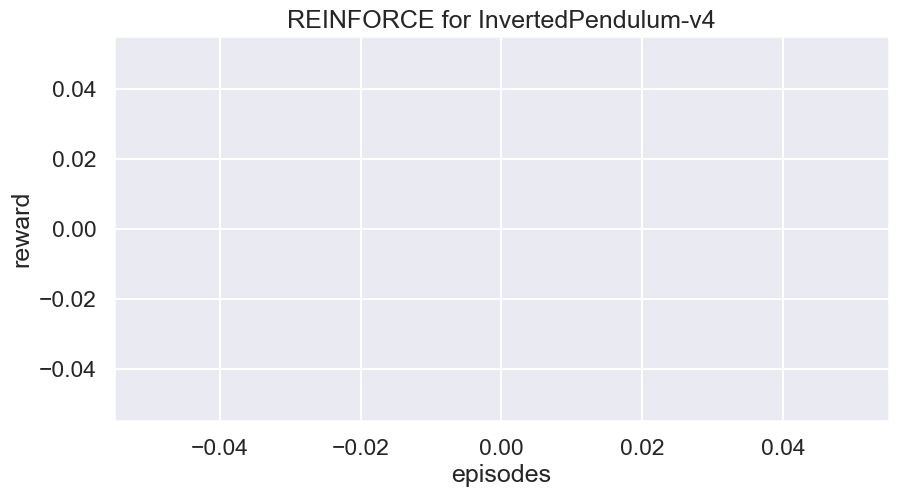

In [46]:
#@title Plotting Results
rewards_to_plot = [[reward[0] for reward in rewards if not isinstance(reward, float)] 
                   for rewards in rewards_over_seeds if not isinstance(rewards, float)]
df1 = pd.DataFrame(rewards_to_plot).melt()
df1.rename(columns={"variable": "episodes", "value": "reward"}, inplace=True)
sns.set(style="darkgrid", context="talk", palette="rainbow")
sns.lineplot(x="episodes", y="reward", data=df1).set(
    title="REINFORCE for InvertedPendulum-v4"
)
plt.show()

In [39]:
env.close()

In [ ]:
# torch.save(agent.net.state_dict(), "/Users/asafr/model-weights/inverted_pendulum_reinforce_policy.pth")

100%|██████████| 3/3 [01:23<00:00, 27.71s/it]

Ran 3 episodes, total steps: 3000

Episode stats:
         step  reward
episode              
0         999  1000.0
1         999  1000.0
2         999  1000.0

Mean:
       step  reward
mean  999.0  1000.0
std     0.0     0.0

Reward Mean ± 95% CI: nan ± nan

Episode 0 - Total Reward: 1000.0, Steps: 1000



/Users/asafr/miniconda3/envs/lerobot/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/Users/asafr/miniconda3/envs/lerobot/lib/python3.10/site-packages/scipy/stats/_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


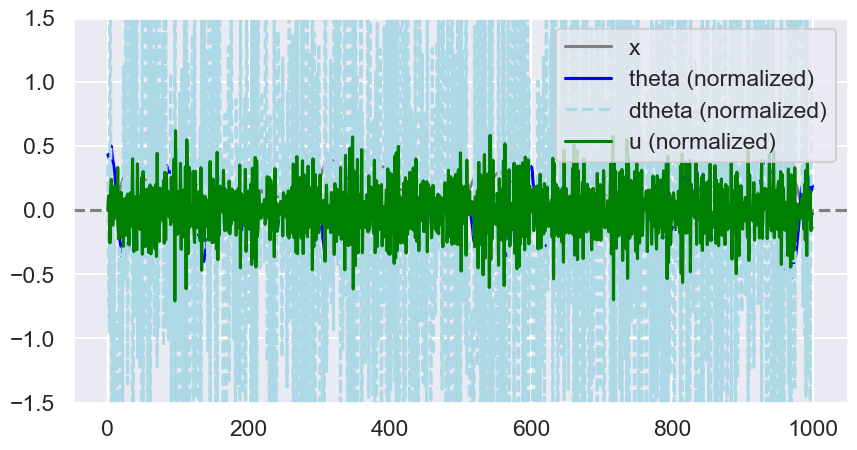

Episode 1 - Total Reward: 1000.0, Steps: 1000


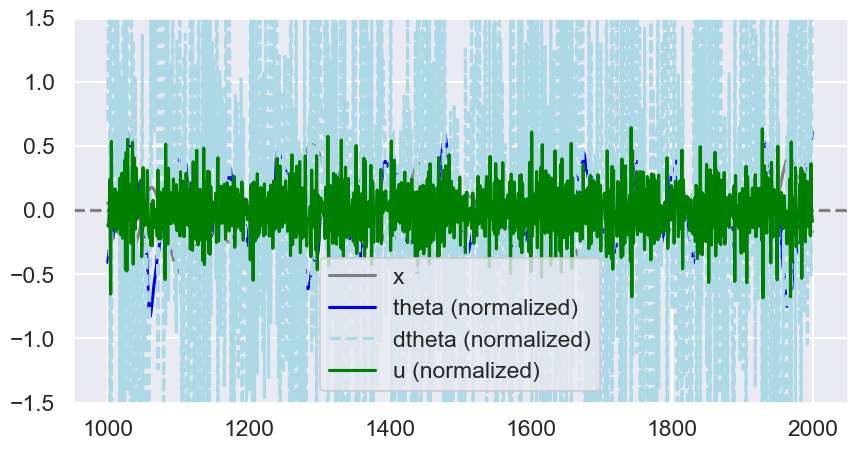

Episode 2 - Total Reward: 1000.0, Steps: 1000


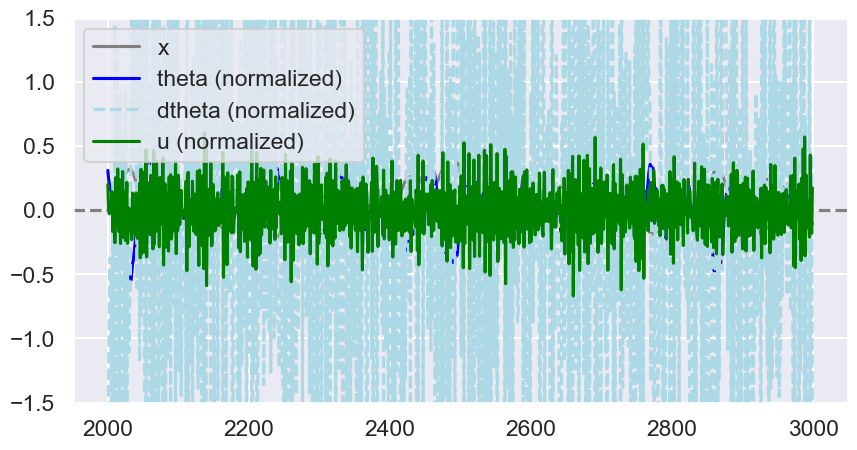

In [61]:
#@title Run a trained policy, on an environment with UI

from lerobot.envs.utils import _load_module_from_path, _call_make_env, _normalize_hub_result

# Load your module
module = _load_module_from_path("./inverted_pendulum_env.py")  # Use the UI version

# Test the make_env function
result = _call_make_env(module, n_envs=1, use_async_envs=False)
normalized = _normalize_hub_result(result)
suite_name = next(iter(normalized))
env = normalized[suite_name][0]


n_episodes = 3
g = 9.81
max_theta = 0.2 # radians
max_u = 3.0

net = agent.net
eps = 1e-6

import numpy as np
def trained_policy(obs, prev_step_df, debug=True) -> np.ndarray:
    state = torch.tensor(np.array([obs]))
    action_means, action_stddevs = net(state)
    distrib = Normal(action_means[0] + eps, action_stddevs[0] + eps)
    action = distrib.sample()
    return action.numpy()



step_log = [
]

def log_step(episode, step, 
             action, post_action_obs, terminated=False, truncated=False, 
             reward=[0.0], info={}):
    x, theta, dx, dtheta = post_action_obs[0]
    step_log.append(
        dict(
            episode=episode,
            step=step,
            action=action,
            u=action[0][0] if action is not None else 0.0,
            x=x,
            theta=theta,
            dx=dx,
            dtheta=dtheta,
            obs=post_action_obs,
            reward=reward[0] if reward is not None else 0.0,
            terminated=terminated,
            truncated=truncated,
            info=info,
        )
    )

import pandas as pd
def make_step_df():
    df = pd.DataFrame.from_records(step_log)
    return df


import time
import tqdm
for episode in tqdm.tqdm(range(n_episodes)):
    obs, info = env.reset()
    reward = 0.0; terminated = False; truncated = False
    step = 0
    while not step_log or (not terminated and not truncated):
        # time.sleep(0.01)  # To slow down the rendering
        df = make_step_df()
        action = trained_policy(obs, df, debug=True)
        obs, reward, terminated, truncated, info = env.step(action)
        log_step(episode, step, action, obs, terminated, truncated, reward, info)
        step += 1

    # print(f'Total steps: {len(step_log)}')


print(f'Ran {n_episodes} episodes, total steps: {len(step_log)}')

step_df = make_step_df()
df = step_df


import scipy.stats as stats
def calculate_mean_and_ci(series):
    # Based on https://www.geeksforgeeks.org/python/how-to-calculate-confidence-intervals-in-python/
    ci = stats.t.interval(
      confidence=0.95, df=len(series)-1, 
      loc=np.mean(series), 
      scale=np.std(series, ddof=1) / np.sqrt(len(series)))
    mean_and_ci = (np.mean(ci), (ci[1] - ci[0]) / 2)
    return mean_and_ci

reward_mean_and_ci = calculate_mean_and_ci(
    df[['episode', 'reward']].groupby('episode', as_index=False).agg({'reward': 'sum'}).reward)

print(f'''
Episode stats:
{df[['episode', 'step', 'reward']].groupby("episode").agg({
    'step': 'max',
    'reward': 'sum',
})}

Mean:
{df[['episode', 'step', 'reward']].groupby("episode").agg({
    'step': 'max',
    'reward': 'sum',
}).agg(['mean', 'std'])}

Reward Mean ± 95% CI: {reward_mean_and_ci[0]:.2f} ± {reward_mean_and_ci[1]:.2f}
''')

from matplotlib import pyplot as plt
for episode in range(n_episodes):
    df = step_df[step_df.episode == episode]
    print(f'Episode {episode} - Total Reward: {df.reward.sum()}, Steps: {len(df)}')
    _ = plt.axhline(0, color='gray', linestyle='--')
    _ = plt.plot(df.index, df.x, label='x', color='gray')
    _ = plt.plot(df.index, df.theta / max_theta, label='theta (normalized)', color='blue')
    _ = plt.plot(df.index, df.dtheta / max_theta, label='dtheta (normalized)', color='lightblue', linestyle='--')
    _ = plt.plot(df.index, df.u / max_u, label='u (normalized)', color='green')
    _ = plt.ylim(-1.5, 1.5)
    _ = plt.legend()
    plt.show()



In [62]:
env.close()
